# Erkennung der Schweißqualität während des Schweißprozesses

## Entwicklung eines datengetriebenen Verfahrens zur Überwachung und Vorhersage der Schweißqualität anhand von induktiven Tasterdaten und thermischen LWIR-Aufnahmen

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

## Analyse der Taster-Werte:

In [2]:
# Betrachtung: 001-000 (Preprocessed)

pfad001_000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")

fuerDataFrame = np.load(pfad001_000Prep)

df001_000Prep = pd.DataFrame(
    {
        "Time (s)": fuerDataFrame[0],
        "Taster 1 (mm)": fuerDataFrame[1],
        "Taster 2 (mm)": fuerDataFrame[2],
        "Taster 3 (mm)": fuerDataFrame[3]
    }
)

display(df001_000Prep[: 100])

print(df001_000Prep.shape)

,Time (s),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710
...,...,...,...,...
95,1.229,0.032382,0.051413,0.069559
96,1.230,0.032539,0.051806,0.070501
97,1.231,0.032539,0.052198,0.071050
98,1.232,0.032853,0.052905,0.071757


(19909, 4)


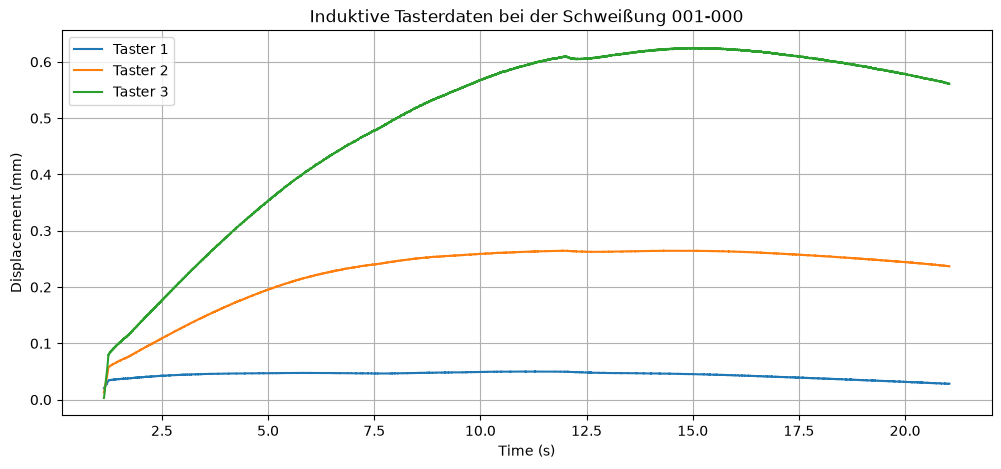

In [3]:
plt.figure(figsize = (12, 5))

plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 1 (mm)"], label="Taster 1")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 2 (mm)"], label="Taster 2")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 3 (mm)"], label="Taster 3")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.title("Induktive Tasterdaten bei der Schweißung 001-000")
plt.legend()
plt.grid()
plt.show()

##### -> Starke Positionsänderungen in Y-Richtung vor allem bei Taster 3. Taster 3 befindet sich an der rechten bzw. endseitigen Messposition des beweglichen Blechs.

#### Und wenn man alle 50 Schweißungen vergleicht innerhalb der Konfiguration 001?

##### Problem:

In [4]:
pfad000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")
pfad015Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-015.npy")

daten000 = np.load(pfad000Prep)
daten015 = np.load(pfad015Prep)

print("001-000 Shape:", daten000.shape)
print("001-015 Shape:", daten015.shape)

001-000 Shape: (4, 19909)
001-015 Shape: (3, 19280)


In [5]:
df000Prep = pd.DataFrame(daten000.T)
df015Prep = pd.DataFrame(daten015.T)

print("001-000:")
display(df000Prep.head(5))

print("001-015:")
display(df015Prep.head(5))

001-000:


,0,1,2,3
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710


001-015:


,0,1,2
0,-0.000094,-0.000060,-0.000037
1,-0.000173,-0.000060,-0.000115
2,-0.000251,-0.000060,-0.000115
3,-0.000173,0.000018,-0.000037
4,-0.000094,-0.000138,-0.000115


##### Shape hat sich verändert ab 015, kein Zeitstempel vorhanden. Bei der Konfiguration 001 hat man auf die ersten 15 einen Zeitstempel und danach nicht mehr.

##### Andere Vorgehensweise um die 50 Schweißungen miteinander zu vergleichen aus Konfiguration 001.

#### Konfiguration 002 hat auch das gleiche Problem?

In [6]:
pfad001Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001")
pfad002Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/002")

print("001 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad001Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

print()
print("002 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad002Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

001 Shape Kontrolle der .npy Dateien:

001-000.npy (4, 19909)
001-001.npy (4, 19496)
001-002.npy (4, 19762)
001-003.npy (4, 19588)
001-004.npy (4, 19833)
001-005.npy (4, 19933)
001-006.npy (4, 19660)
001-007.npy (4, 19887)
001-008.npy (4, 19869)
001-009.npy (4, 19126)
001-010.npy (4, 19916)
001-011.npy (4, 19516)
001-012.npy (4, 19801)
001-013.npy (4, 19816)
001-014.npy (4, 19852)
001-015.npy (3, 19280)
001-016.npy (3, 19280)
001-017.npy (3, 19280)
001-018.npy (3, 19280)
001-019.npy (3, 19280)
001-020.npy (3, 19280)
001-021.npy (3, 19280)
001-022.npy (3, 19280)
001-023.npy (3, 19280)
001-024.npy (3, 19279)


001-025.npy (3, 19279)
001-026.npy (3, 19280)
001-027.npy (3, 19280)
001-028.npy (3, 19280)
001-029.npy (3, 19280)
001-030.npy (3, 19279)
001-031.npy (3, 19279)
001-032.npy (3, 19279)
001-033.npy (3, 19280)
001-034.npy (3, 19280)
001-035.npy (3, 19280)
001-036.npy (3, 19280)
001-037.npy (3, 19280)
001-038.npy (3, 19280)
001-039.npy (3, 19280)
001-040.npy (3, 19280)
001-041.npy (3, 19280)
001-042.npy (3, 19280)
001-043.npy (3, 19280)
001-044.npy (3, 19280)
001-045.npy (3, 19280)
001-046.npy (3, 19280)
001-047.npy (3, 19280)
001-048.npy (3, 19279)
001-049.npy (3, 19279)

002 Shape Kontrolle der .npy Dateien:

002-000.npy (4, 3781)
002-001.npy (4, 3851)
002-002.npy (4, 3848)
002-003.npy (4, 3912)
002-004.npy (4, 3909)
002-005.npy (4, 3817)
002-006.npy (4, 3824)
002-007.npy (4, 3884)
002-008.npy (4, 3839)
002-009.npy (4, 3759)
002-010.npy (4, 3805)
002-011.npy (4, 3903)
002-012.npy (4, 3897)
002-013.npy (4, 3881)
002-014.npy (4, 3893)
002-015.npy (3, 4220)
002-016.npy (3, 4221)
002-017.npy

##### Beide Konfigurationen haben ab 015 Shape (3, n).

##### -> Bei Shape (3, n) wird die extra Zeitstempel-Spalte künstlich erzeugt um Shape zu erweitern, mithilfe von arange().

In [7]:
alleDataFrames001 = []

for datei in sorted(pfad001Prep.glob("*.npy")):

    daten = np.load(datei).T

    if daten.shape[1] == 4:

        df = pd.DataFrame(
            daten,
            columns = [
                "Time (s)",
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time Type"] = "original"

    elif daten.shape[1] == 3:

        df = pd.DataFrame(
            daten,
            columns = [
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time (s)"] = np.arange(len(df)) / 1000
        df["Time Type"] = "reconstructed"

    df["ID"] = datei.stem

    df = df[ # Reihenfolge ändern
        [
            "ID",
            "Time (s)",
            "Time Type",
            "Taster 1 (mm)",
            "Taster 2 (mm)",
            "Taster 3 (mm)"
        ]
    ]

    alleDataFrames001.append(df)

dataFrameAlleDataFrames001 = pd.concat(alleDataFrames001, ignore_index = True)

display(dataFrameAlleDataFrames001.head(5))
print("Shape: ", dataFrameAlleDataFrames001.shape)

,ID,Time (s),Time Type,Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,001-000,1.134,original,0.020373,0.012720,0.003004
1,001-000,1.135,original,0.020452,0.012877,0.003161
2,001-000,1.136,original,0.020530,0.013034,0.003396
3,001-000,1.137,original,0.020687,0.013270,0.003553
4,001-000,1.138,original,0.020530,0.013505,0.003710


Shape:  (970757, 6)


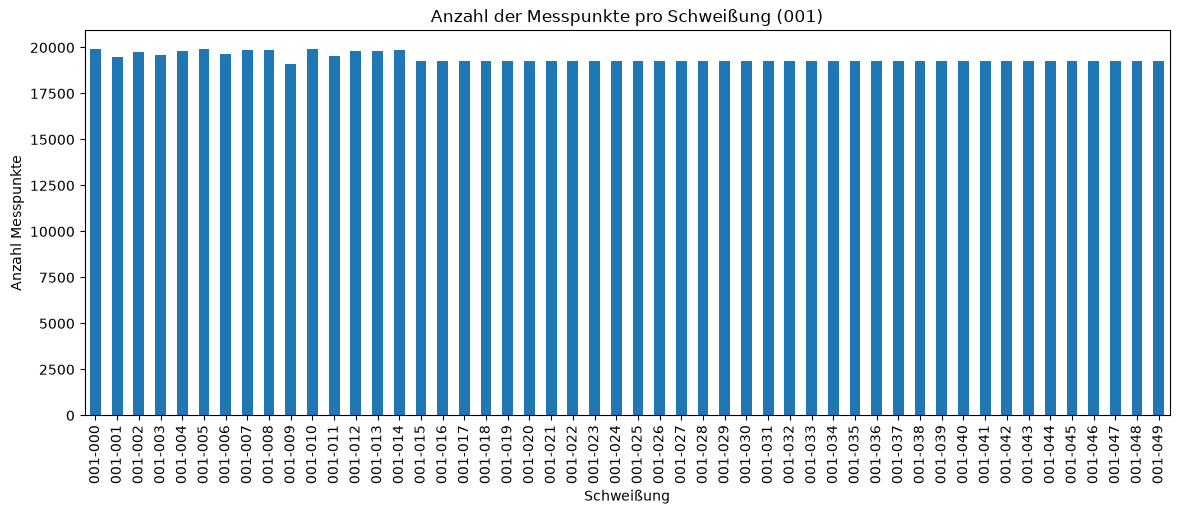

In [8]:
messpunkteProWelding = dataFrameAlleDataFrames001.groupby("ID").size()


plt.figure(figsize = (14, 5))

messpunkteProWelding.plot(kind = "bar")

plt.xlabel("Schweißung")
plt.ylabel("Anzahl Messpunkte")
plt.title("Anzahl der Messpunkte pro Schweißung (001)")
plt.show()

#### Um das typische Bewegungsverhalten des beweglichen Blechs zu untersuchen, werden alle 50 Schweißungen der Konfiguration 001 miteinander verglichen.

#### Da die einzelnen Schweißungen unterschiedlich viele Messpunkte enthalten, ist es nötig die Taster-Zeitreihen zunächst auf eine bestimmte Anzahl an relativer Positionen zwischen 0 % und 100 % des Schweißverlaufs zu interpolieren, zum Beispiel auf 200 Positionen.

#### Anschließend soll für jede relative Position der Median der Tasterwerte über alle 50 Schweißungen berechnet werden.

#### Zusätzlich wird das 25%- und 75%-Quantil bestimmt. Der Bereich zwischen Q25 und Q75 beinhaltet die mittleren 50 % der Schweißungen und zeigt damit, wie stark die Tasterwerte zwischen den einzelnen Schweißungen streuen.

#### Die Analyse wird separat für Taster 1, Taster 2 und Taster 3 durchgeführt.

In [9]:
anzahlMesswerte = 200

verlaufTaster1 = []
verlaufTaster2 = []
verlaufTaster3 = []

# Beispiel: id = "001-000", gruppe = DataFrame mit allen Zeilen von 001-000

for id, gruppe in dataFrameAlleDataFrames001.groupby("ID"):

    # Jede Schweißung mit sehr vielen & unterschiedlichen Messpunkten wird auf genau 200 vergleichbare Postionen gebracht

    alt = np.linspace(0, 1, len(gruppe))
    neu = np.linspace(0, 1, anzahlMesswerte)

    taster1Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 1 (mm)"]
    )

    taster2Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 2 (mm)"]
    )

    taster3Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 3 (mm)"]
    )

    verlaufTaster1.append(taster1Interpoliert)
    verlaufTaster2.append(taster2Interpoliert)
    verlaufTaster3.append(taster3Interpoliert)

In [10]:
verlaufTaster1 = np.array(verlaufTaster1)
verlaufTaster2 = np.array(verlaufTaster2)
verlaufTaster3 = np.array(verlaufTaster3)

print(verlaufTaster1.shape)
print(verlaufTaster2.shape)
print(verlaufTaster3.shape)

(50, 200)
(50, 200)
(50, 200)


In [11]:
medianVerlaufTaster1 = np.median(verlaufTaster1, axis = 0)
medianVerlaufTaster2 = np.median(verlaufTaster2, axis = 0)
medianVerlaufTaster3 = np.median(verlaufTaster3, axis = 0)

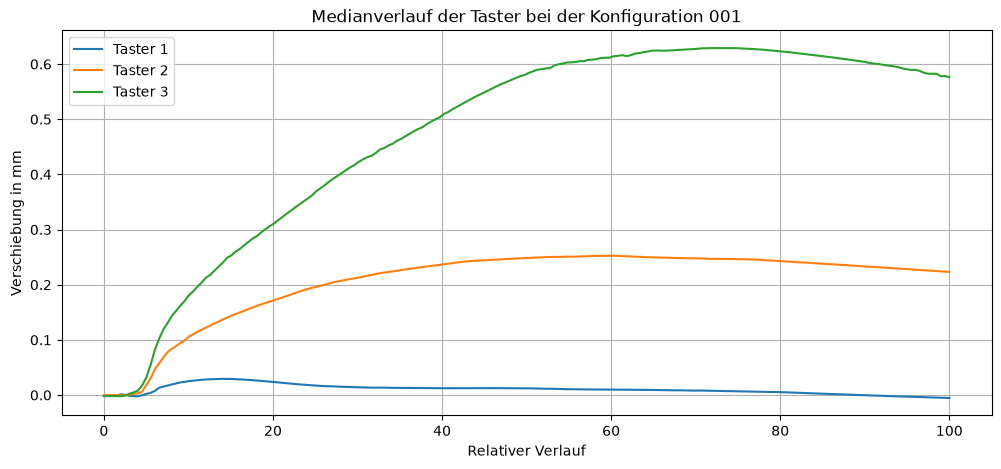

In [12]:
xAchse = np.linspace(0, 100, anzahlMesswerte) # Relativer Verlauf

plt.figure(figsize = (12, 5))

plt.plot(xAchse, medianVerlaufTaster1, label = "Taster 1")
plt.plot(xAchse, medianVerlaufTaster2, label = "Taster 2")
plt.plot(xAchse, medianVerlaufTaster3, label = "Taster 3")

plt.xlabel("Relativer Verlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Medianverlauf der Taster bei der Konfiguration 001")
plt.legend()
plt.grid()
plt.show()

In [13]:
q25Taster1 = np.quantile(verlaufTaster1, 0.25, axis = 0)
q75Taster1 = np.quantile(verlaufTaster1, 0.75, axis = 0)

q25Taster2 = np.quantile(verlaufTaster2, 0.25, axis = 0)
q75Taster2 = np.quantile(verlaufTaster2, 0.75, axis = 0)

q25Taster3 = np.quantile(verlaufTaster3, 0.25, axis = 0)
q75Taster3 = np.quantile(verlaufTaster3, 0.75, axis = 0)

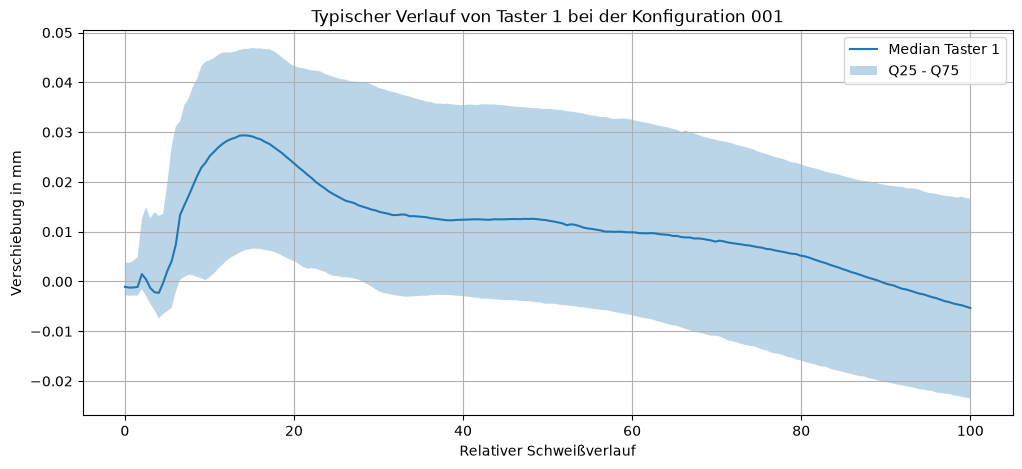

In [14]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster1,
    label = "Median Taster 1"
)

plt.fill_between(
    xAchse,
    q25Taster1,
    q75Taster1,
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 1 bei der Konfiguration 001")
plt.legend()
plt.grid()
plt.show()

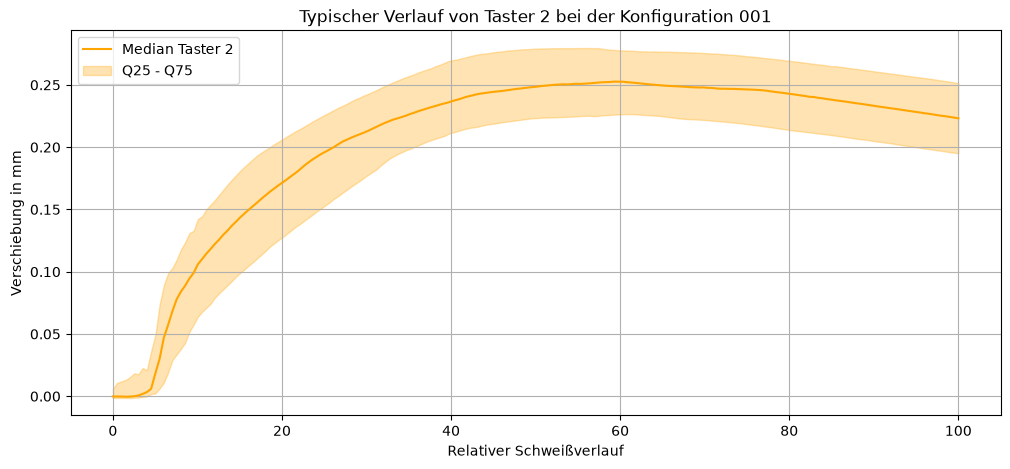

In [15]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster2,
    color = "orange",
    label = "Median Taster 2"
)

plt.fill_between(
    xAchse,
    q25Taster2,
    q75Taster2,
    color = "orange",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 2 bei der Konfiguration 001")
plt.legend()
plt.grid()
plt.show()

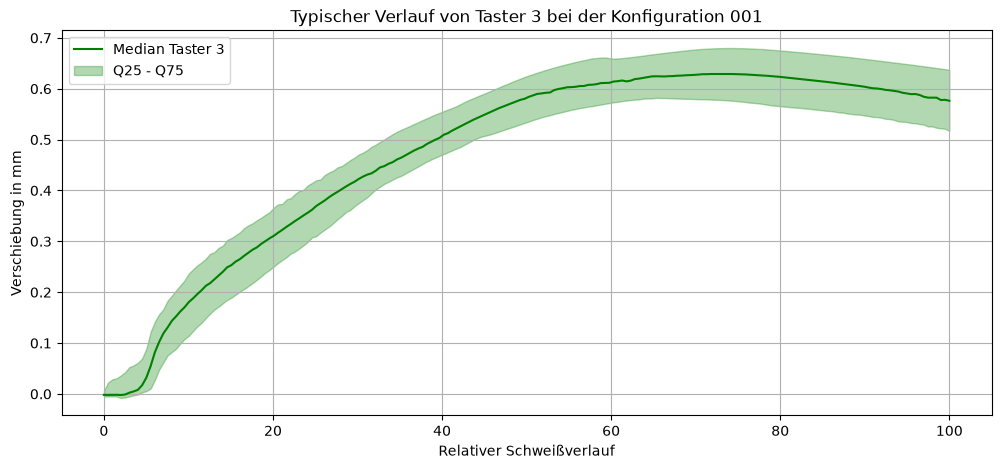

In [16]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster3,
    color = "green",
    label = "Median Taster 3"
)

plt.fill_between(
    xAchse,
    q25Taster3,
    q75Taster3,
    color = "green",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 3 bei der Konfiguration 001")
plt.legend()
plt.grid()
plt.show()

##### Die Medianverläufe zeigen, dass sich das bewegliche Blech an den drei Tasterpositionen unterschiedlich stark in Y-Richtung bewegt. Das erkennt man aber auch an der jeweiligen Y-Achse bei den 3 Diagrammen, wo auch die Q-Bereiche sichtbar sind.

##### Bei allen drei Tastern steigt die Verschiebung zunächst an und gegen Ende des Schweißverlaufs nehmen die Medianwerte ab, was auf eine Rückbewegung des Blechs hindeutet. Dies deutet darauf hin, dass sich das bewegliche Blech während des Schweißprozesses aufgrund der thermischen Belastung zunehmend bewegt und sich verformt.

##### Das Q25-Q75-Streuungsband scheint bei Taster 3 am schmalsten zu sein im Verhältnis zum Medianverlauf und deutet deshalb bei sich am meisten auf ein ähnlicheres Bewegungsverhalten.

#### Das gleiche bei der Konfiguration 002:

##### Betrachten wir zuerst die erste Schweißung von 002 als DataFrame:

In [17]:
Pfad002_000 = Path("../data/Dataset/Preprocessed/Inductiv_Probes/002/002-000.npy")

data = np.load(Pfad002_000)

dataFrame002_000 = pd.DataFrame(
    data
)

display(dataFrame002_000[: 5].T)

,0,1,2,3
0,0.346,-0.013442,0.002410,0.015417
1,0.347,-0.013442,0.002410,0.015417
2,0.348,-0.013442,0.002410,0.015339
3,0.349,-0.013364,0.002488,0.015260
4,0.350,-0.013521,0.002488,0.015574
...,...,...,...,...
3776,4.122,-0.006457,0.079168,0.177254
3777,4.123,-0.006378,0.079168,0.177332
3778,4.124,-0.006457,0.079090,0.177332
3779,4.125,-0.006300,0.079090,0.177097


In [18]:
alleDataFrames002 = []

for datei in sorted(pfad002Prep.glob("*.npy")):
    daten = np.load(datei).T

    if daten.shape[1] == 4:

        df = pd.DataFrame(
            daten,
            columns = [
                "Time (s)",
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time Type"] = "original"

    elif daten.shape[1] == 3:

        df = pd.DataFrame(
            daten,
            columns = [
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time (s)"] = np.arange(len(df)) / 1000
        df["Time Type"] = "reconstructed"

    df["ID"] = datei.stem

    df = df[
        [
            "ID",
            "Time (s)",
            "Time Type",
            "Taster 1 (mm)",
            "Taster 2 (mm)",
            "Taster 3 (mm)"
        ]
    ]

    alleDataFrames002.append(df)

dataFrameAlleDataFrames002 = pd.concat(alleDataFrames002, ignore_index = True)

display(dataFrameAlleDataFrames002.head(5))
print("Shape: ", dataFrameAlleDataFrames002.shape)

,ID,Time (s),Time Type,Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,002-000,0.346,original,-0.013442,0.002410,0.015417
1,002-000,0.347,original,-0.013442,0.002410,0.015417
2,002-000,0.348,original,-0.013442,0.002410,0.015339
3,002-000,0.349,original,-0.013364,0.002488,0.015260
4,002-000,0.350,original,-0.013521,0.002488,0.015574


Shape:  (205505, 6)


In [19]:
verlaufTaster1_2 = []
verlaufTaster2_2 = []
verlaufTaster3_2 = []

for id, gruppe in dataFrameAlleDataFrames002.groupby("ID"):

    alt = np.linspace(0, 1, len(gruppe))
    neu = np.linspace(0, 1, anzahlMesswerte)

    taster1Interpoliert_2 = np.interp(
        neu,
        alt,
        gruppe["Taster 1 (mm)"]
    )

    taster2Interpoliert_2 = np.interp(
        neu,
        alt,
        gruppe["Taster 2 (mm)"]
    )

    taster3Interpoliert_2 = np.interp(
        neu,
        alt,
        gruppe["Taster 3 (mm)"]
    )

    verlaufTaster1_2.append(taster1Interpoliert_2)
    verlaufTaster2_2.append(taster2Interpoliert_2)
    verlaufTaster3_2.append(taster3Interpoliert_2)

In [20]:
verlaufTaster1_2 = np.array(verlaufTaster1_2)
verlaufTaster2_2 = np.array(verlaufTaster2_2)
verlaufTaster3_2 = np.array(verlaufTaster3_2)

print(verlaufTaster1_2.shape)
print(verlaufTaster2_2.shape)
print(verlaufTaster3_2.shape)

(50, 200)
(50, 200)
(50, 200)


In [21]:
medianVerlaufTaster1_2 = np.median(verlaufTaster1_2, axis = 0)
medianVerlaufTaster2_2 = np.median(verlaufTaster2_2, axis = 0)
medianVerlaufTaster3_2 = np.median(verlaufTaster3_2, axis = 0)

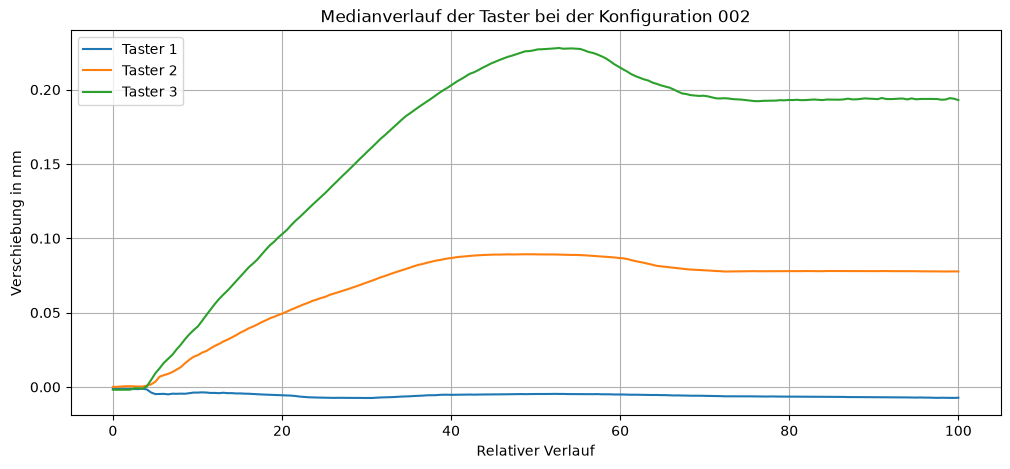

In [22]:
plt.figure(figsize = (12, 5))

plt.plot(xAchse, medianVerlaufTaster1_2, label = "Taster 1")
plt.plot(xAchse, medianVerlaufTaster2_2, label = "Taster 2")
plt.plot(xAchse, medianVerlaufTaster3_2, label = "Taster 3")

plt.xlabel("Relativer Verlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Medianverlauf der Taster bei der Konfiguration 002")
plt.legend()
plt.grid()
plt.show()

In [23]:
q25Taster1_2 = np.quantile(verlaufTaster1_2, 0.25, axis = 0)
q75Taster1_2 = np.quantile(verlaufTaster1_2, 0.75, axis = 0)

q25Taster2_2 = np.quantile(verlaufTaster2_2, 0.25, axis = 0)
q75Taster2_2 = np.quantile(verlaufTaster2_2, 0.75, axis = 0)

q25Taster3_2 = np.quantile(verlaufTaster3_2, 0.25, axis = 0)
q75Taster3_2 = np.quantile(verlaufTaster3_2, 0.75, axis = 0)

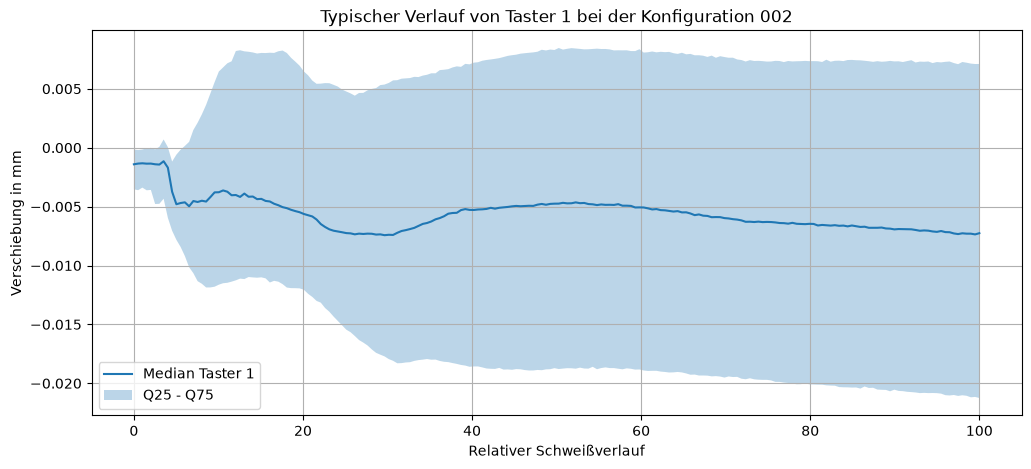

In [24]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster1_2,
    label = "Median Taster 1"
)

plt.fill_between(
    xAchse,
    q25Taster1_2,
    q75Taster1_2,
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 1 bei der Konfiguration 002")
plt.legend()
plt.grid()
plt.show()

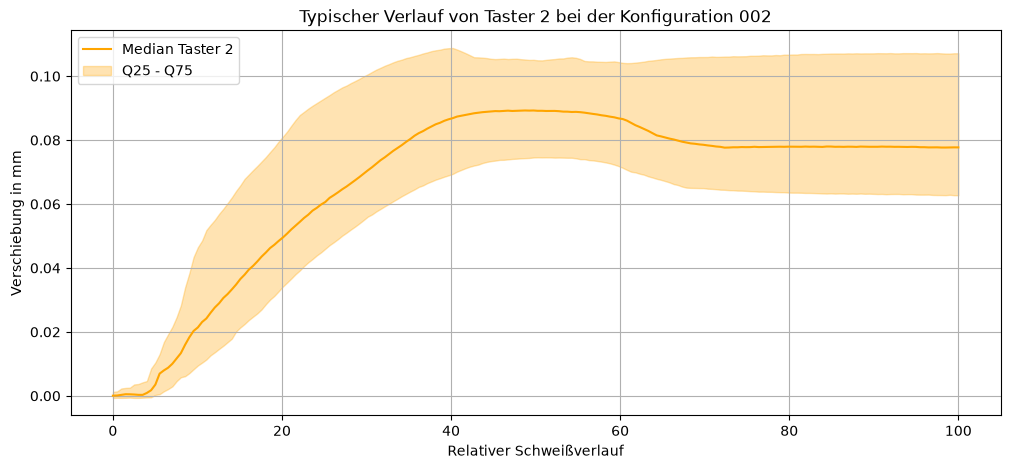

In [25]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster2_2,
    color = "orange",
    label = "Median Taster 2"
)

plt.fill_between(
    xAchse,
    q25Taster2_2,
    q75Taster2_2,
    color = "orange",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 2 bei der Konfiguration 002")
plt.legend()
plt.grid()
plt.show()

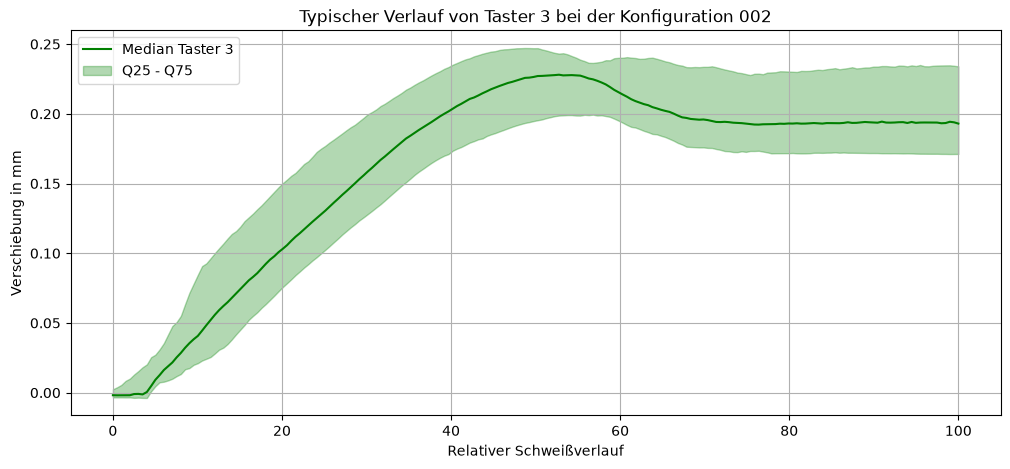

In [26]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster3_2,
    color = "green",
    label = "Median Taster 3"
)

plt.fill_between(
    xAchse,
    q25Taster3_2,
    q75Taster3_2,
    color = "green",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 3 bei der Konfiguration 002")
plt.legend()
plt.grid()
plt.show()

#### Direkter vergleich der beiden Konfigurationen (Subplot):

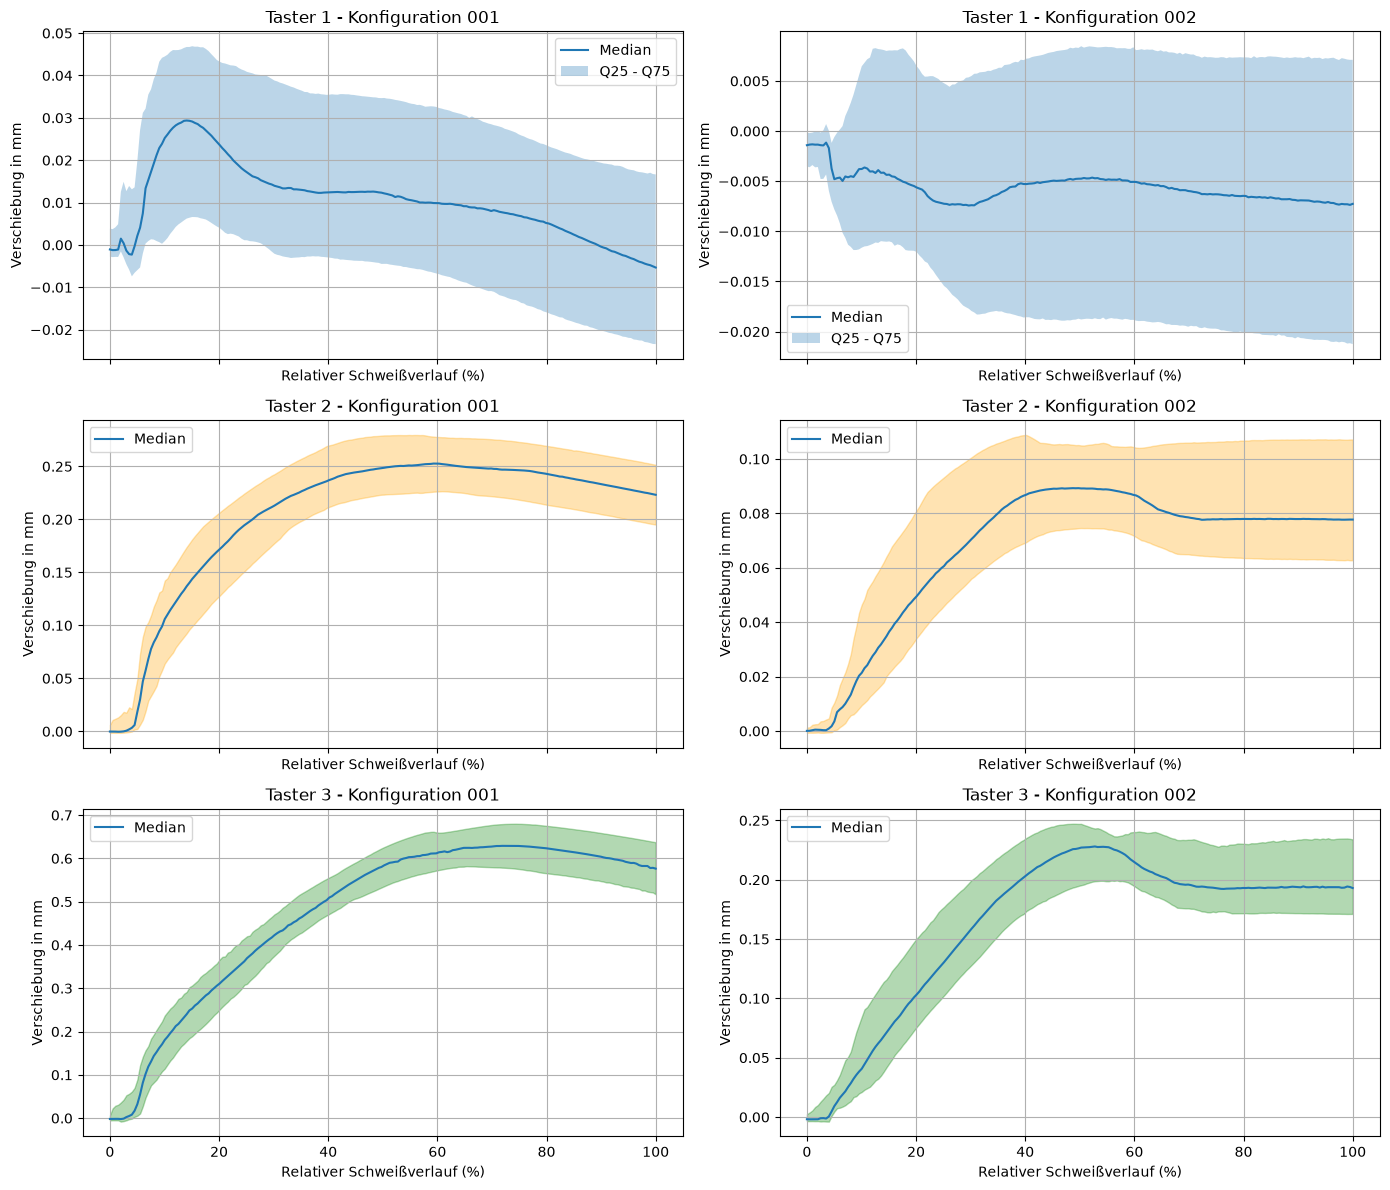

In [27]:
fig, axes = plt.subplots(3, 2, figsize = (14, 12), sharex=True)

axes[0, 0].plot(
    xAchse,
    medianVerlaufTaster1,
    label="Median"
)

axes[0, 0].fill_between(
    xAchse,
    q25Taster1,
    q75Taster1,
    alpha=0.3,
    label="Q25 - Q75"
)

axes[0, 0].set_title("Taster 1 - Konfiguration 001")

axes[0, 1].plot(
    xAchse,
    medianVerlaufTaster1_2,
    label="Median"
)

axes[0, 1].fill_between(
    xAchse,
    q25Taster1_2,
    q75Taster1_2,
    alpha=0.3,
    label="Q25 - Q75"
)

axes[0, 1].set_title("Taster 1 - Konfiguration 002")

axes[1, 0].plot(
    xAchse,
    medianVerlaufTaster2,
    label="Median"
)

axes[1, 0].fill_between(
    xAchse,
    q25Taster2,
    q75Taster2,
    color = "orange",
    alpha=0.3
)

axes[1, 0].set_title("Taster 2 - Konfiguration 001")

axes[1, 1].plot(
    xAchse,
    medianVerlaufTaster2_2,
    label="Median"
)

axes[1, 1].fill_between(
    xAchse,
    q25Taster2_2,
    q75Taster2_2,
    color = "orange",
    alpha=0.3
)

axes[1, 1].set_title("Taster 2 - Konfiguration 002")

axes[2, 0].plot(
    xAchse,
    medianVerlaufTaster3,
    label="Median"
)

axes[2, 0].fill_between(
    xAchse,
    q25Taster3,
    q75Taster3,
    color = "green",
    alpha=0.3
)

axes[2, 0].set_title("Taster 3 - Konfiguration 001")

axes[2, 1].plot(
    xAchse,
    medianVerlaufTaster3_2,
    label="Median"
)

axes[2, 1].fill_between(
    xAchse,
    q25Taster3_2,
    q75Taster3_2,
    color = "green",
    alpha=0.3
)

axes[2, 1].set_title("Taster 3 - Konfiguration 002")

for ax in axes.flat:
    ax.set_xlabel("Relativer Schweißverlauf (%)")
    ax.set_ylabel("Verschiebung in mm")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

##### Die Konfiguration 001 zeigt eine größere absolute Verschiebung (Y-Achse).

In [28]:
taster1Bandbreite001 = q75Taster1 - q25Taster1
taster1Bandbreite002 = q75Taster1_2 - q25Taster1_2

taster2Bandbreite001 = q75Taster2 - q25Taster2
taster2Bandbreite002 = q75Taster2_2 - q25Taster2_2

taster3Bandbreite001 = q75Taster3 - q25Taster3
taster3Bandbreite002 = q75Taster3_2 - q25Taster3_2

print(taster1Bandbreite001.shape)
print(taster2Bandbreite001.shape)

(200,)
(200,)


In [29]:
print("001:")
print(taster1Bandbreite001.mean())
print(taster2Bandbreite001.mean())
print(taster3Bandbreite001.mean())

print()

print("002:")
print(taster1Bandbreite002.mean())
print(taster2Bandbreite002.mean())
print(taster3Bandbreite002.mean())


001:
0.03812634312648079
0.058939301138865405
0.09847557190147224

002:
0.023624390627113537
0.03776164719407107
0.05745374607821785


##### Die absolute Streuung der Y-Verschiebungen zwischen den 50 Schweißungen ist bei der Konfiguration 002 geringer als bei der Konfiguration 001.

#### An welcher Stelle ist ist Bandbreite groß, also wann unterscheiden sich die Schweißungen mehr?

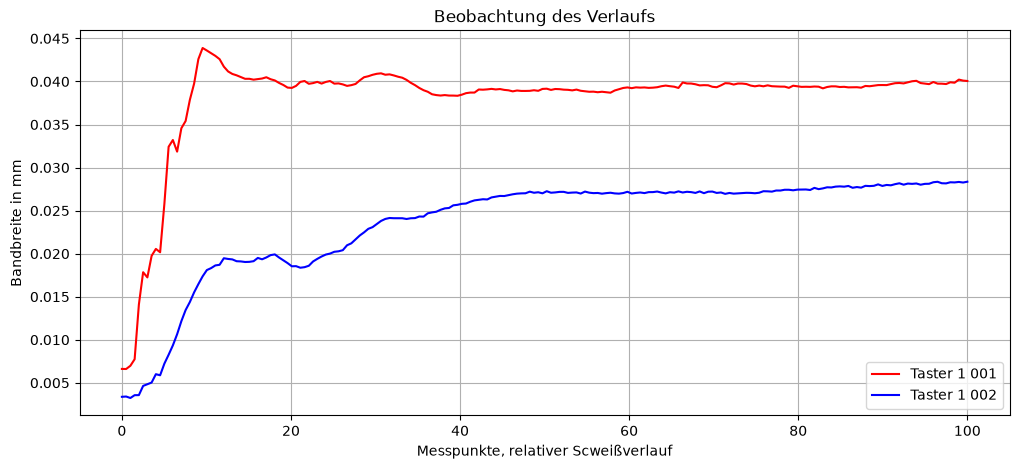

In [30]:
plt.figure( figsize = (12, 5))

plt.plot(xAchse, taster1Bandbreite001, color = "red", label = "Taster 1 001")
plt.plot(xAchse, taster1Bandbreite002, color = "blue", label = "Taster 1 002")

plt.xlabel("Messpunkte, relativer Scweißverlauf")
plt.ylabel("Bandbreite in mm")
plt.title("Beobachtung des Verlaufs")

plt.legend()
plt.grid()
plt.show()

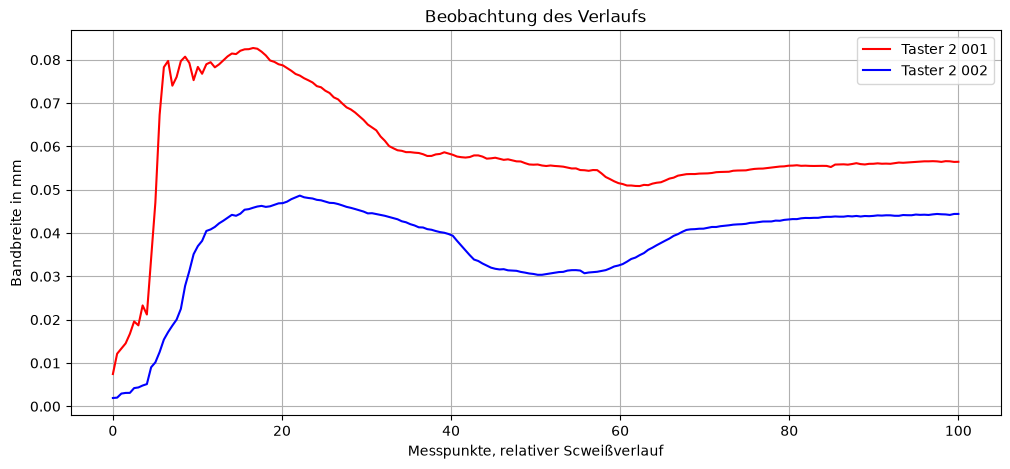

In [31]:
plt.figure( figsize = (12, 5))

plt.plot(xAchse, taster2Bandbreite001, color = "red", label = "Taster 2 001")
plt.plot(xAchse, taster2Bandbreite002, color = "blue", label = "Taster 2 002")

plt.xlabel("Messpunkte, relativer Scweißverlauf")
plt.ylabel("Bandbreite in mm")
plt.title("Beobachtung des Verlaufs")

plt.legend()
plt.grid()
plt.show()

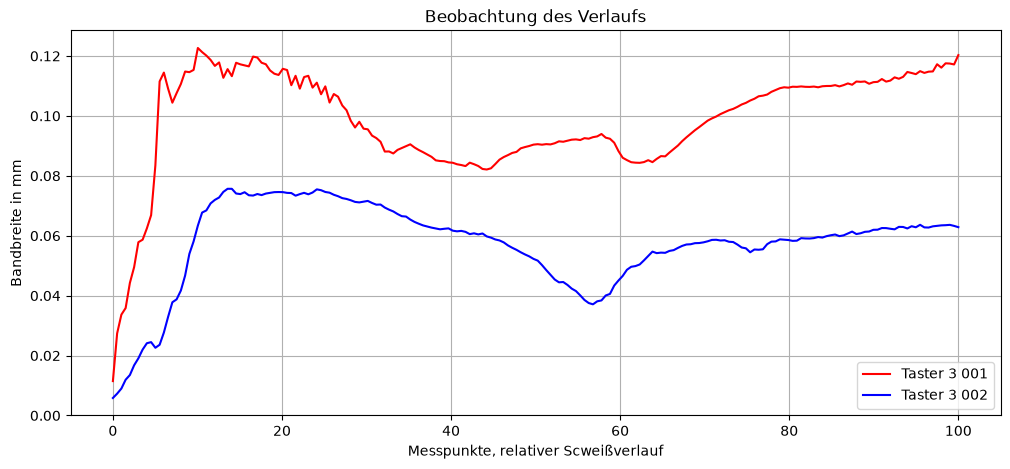

In [32]:
plt.figure( figsize = (12, 5))

plt.plot(xAchse, taster3Bandbreite001, color = "red", label = "Taster 3 001")
plt.plot(xAchse, taster3Bandbreite002, color = "blue", label = "Taster 3 002")

plt.xlabel("Messpunkte, relativer Scweißverlauf")
plt.ylabel("Bandbreite in mm")
plt.title("Beobachtung des Verlaufs")

plt.legend()
plt.grid()
plt.show()

## Analyse von LWIR + Labels:

- Bei 001-000 beginnt der sound-Ordner bei Frame 31 und bei unsound beginnt bei 146.

- Bei 001-001 beginnt sound dagegen erst bei 35 und unsound bei 161.

- Im Ordner ,,Labeled_Frames" sieht man nur sound und unsound, obwohl bei dem Ordner ,,Labels" auch sowas wie ,,Beginning" gibt, existiert dennoch bei Labeled_Frames nicht.

- Grund ist es vermutlich, dass jede Schweißung thermisch und geometrisch etwas anders verläuft, weshalb der Übergang von `Beginning - Sound - Unsound` nicht bei exakt derselben Framenummer (= .tiff Datei ) auftritt.

- Die Frame-Nummer ist nur die zeitliche Reihenfolge der LWIR-Aufnahmen innerhalb einer Schweißung.

- Sound und Unsound beziehen sich auf den lokalen Zustand des gerade betrachteten LWIR-Frames, nicht automatisch auf die gesamte Schweißnaht.

In [33]:
pfadLabels = Path("../data/Dataset/Preprocessed/LWIR/Labels")

alleLabels = []

for i in sorted(pfadLabels.glob("*.csv")):
    
    df = pd.read_csv(
        i
    )

    df["ID"] = i.stem

    alleLabels.append(df)

dataFrameAlleLabels = pd.concat(alleLabels, ignore_index = True)

In [34]:
labelVerteilungProWelding = (
    
    dataFrameAlleLabels.groupby(["ID", "Label"]).size().unstack(fill_value = 0)

)

print(labelVerteilungProWelding.head().to_string())

Label    Beginning  Sound  Unsound
ID                                
001-000         31    115       73
001-001         35    126       58
001-002         34    115       69
001-003         33    123       63
001-004         33    118       68


#### Bei jeder Schweißung den ersten Unsound-Frame bestimmen (beide Konfigurationen):

In [35]:
firstUnsoundPerWeld = (
    
    dataFrameAlleLabels[
         dataFrameAlleLabels["Label"] == "Unsound"
    ]

    .groupby("ID")["Frame"]
    .min()

)

#### Das gleiche bei Sound und den letzten Frame herausfinden, danach ein DataFrame daraus basteln:

In [36]:
firstSoundPerWeld = (
    
    dataFrameAlleLabels[
        dataFrameAlleLabels["Label"] == "Sound"
        ]

    .groupby("ID")["Frame"]
    .min()
)

In [37]:
lastFramePerWeld = (

    dataFrameAlleLabels
    .groupby("ID")["Frame"]
    .max()

)

In [38]:
df_LWIR_Overview = pd.DataFrame(
    {
        "1st Sound Frame": firstSoundPerWeld,
        "1st Unsound Frame": firstUnsoundPerWeld,
        "Last Frame": lastFramePerWeld,
        "Anzahl Beginning": labelVerteilungProWelding["Beginning"],
        "Anzahl Sound": labelVerteilungProWelding["Sound"],
        "Anzahl Unsound": labelVerteilungProWelding["Unsound"]
    }
)

#### Beginning wird mitberücksichtigt.

In [39]:
df_LWIR_Overview["Sound Anteil %"] = (

    df_LWIR_Overview["Anzahl Sound"] / ( df_LWIR_Overview["Anzahl Sound"] + df_LWIR_Overview["Anzahl Unsound"] + df_LWIR_Overview["Anzahl Beginning"]) * 100
    
    )


df_LWIR_Overview["Unsound Anteil %"] = (

    df_LWIR_Overview["Anzahl Unsound"] / ( df_LWIR_Overview["Anzahl Sound"] + df_LWIR_Overview["Anzahl Unsound"] + df_LWIR_Overview["Anzahl Beginning"]) * 100
    
    )

df_LWIR_Overview["Beginning Anteil %"] = (

    df_LWIR_Overview["Anzahl Beginning"] / ( df_LWIR_Overview["Anzahl Sound"] + df_LWIR_Overview["Anzahl Unsound"] + df_LWIR_Overview["Anzahl Beginning"]) * 100
    
    )

In [40]:
df_LWIR_Overview["Konfiguration"] = (
    df_LWIR_Overview.index
    .str.split("-")
    .str[0]
)

In [41]:
display(df_LWIR_Overview)

,1st Sound Frame,1st Unsound Frame,Last Frame,Anzahl Beginning,Anzahl Sound,Anzahl Unsound,Sound Anteil %,Unsound Anteil %,Beginning Anteil %,Konfiguration
ID,,,,,,,,,,
001-000,31,146,218,31,115,73,52.511416,33.333333,14.155251,001
001-001,35,161,218,35,126,58,57.534247,26.484018,15.981735,001
001-002,34,149,217,34,115,69,52.752294,31.651376,15.596330,001
001-003,33,156,218,33,123,63,56.164384,28.767123,15.068493,001
001-004,33,151,218,33,118,68,53.881279,31.050228,15.068493,001
...,...,...,...,...,...,...,...,...,...,...
002-044,16,47,72,16,31,26,42.465753,35.616438,21.917808,002
002-045,15,47,75,15,32,29,42.105263,38.157895,19.736842,002
002-046,16,48,74,16,32,27,42.666667,36.000000,21.333333,002


In [42]:
vergleichKonfigurationen = (

    df_LWIR_Overview
    
    .groupby("Konfiguration")[
        [
            "Sound Anteil %",
            "Unsound Anteil %",
            "Beginning Anteil %"
        ]
    ]
    
    .mean()
)

display(vergleichKonfigurationen)

,Sound Anteil %,Unsound Anteil %,Beginning Anteil %
Konfiguration,,,
001,55.066865,26.619786,18.313349
002,48.247642,32.975254,18.777104


In [43]:
pfadLabeled_Frames = Path("../data/Dataset/Preprocessed/LWIR/Labeled_Frames")

alleFrames = [] # beinhaltet die Dictionaries zu jedem Frame

for ordner in sorted(pfadLabeled_Frames.iterdir()):

    weldID = ordner.name

    konfiguration = weldID.split("-")[0] # "001-000" -> ["001", "000"] -> "001"

    for label in ["sound", "unsound"]:
        labelOrdner = ordner / label

        for bildpfad in sorted(labelOrdner.glob("*.tiff")):

            frameNummer = int(
                bildpfad.stem.split("-")[-1]       
            )
                              
            alleFrames.append(
                {
                    "ID": weldID,
                    "Frame": frameNummer,
                    "Label": label.capitalize(),
                    "Konfiguration": konfiguration,
                    "Bildpfad": bildpfad
                }
            )

df_LWIR_Frames = pd.DataFrame(
    alleFrames
)

display(df_LWIR_Frames.head())
print(df_LWIR_Frames.shape)


,ID,Frame,Label,Konfiguration,Bildpfad
0,001-000,31,Sound,001,../data/Dataset/Preprocessed/LWIR/Labeled_Fram...
1,001-000,32,Sound,001,../data/Dataset/Preprocessed/LWIR/Labeled_Fram...
2,001-000,33,Sound,001,../data/Dataset/Preprocessed/LWIR/Labeled_Fram...
3,001-000,34,Sound,001,../data/Dataset/Preprocessed/LWIR/Labeled_Fram...
4,001-000,35,Sound,001,../data/Dataset/Preprocessed/LWIR/Labeled_Fram...


(16362, 5)


In [44]:
print(df_LWIR_Frames["Label"].value_counts())

Label
Sound      10877
Unsound     5485
Name: count, dtype: int64


In [45]:
erstesBildPfad = df_LWIR_Frames.iloc[0]["Bildpfad"]

bild = Image.open(erstesBildPfad)

print("Bildgröße: ", bild.size)

Bildgröße:  (32, 32)


In [46]:
print("Bildmodus:", bild.mode) # Interpretation der Pixel im Bild

Bildmodus: I;16


##### 16-Bit-Graustufenbild <=> I;16

#### Splitten:

##### Nutzen GroupShuffleSplit damit nach Gruppen gesplittet wird. Eine komplette Schweißung wird entweder Test oder Train, aber es wird nicht so gesplittet, dass innerhalb einer Schweißung etwas Train und Test wird.

In [47]:
from sklearn.model_selection import GroupShuffleSplit

In [48]:
splitter = GroupShuffleSplit(
    n_splits = 1, # Genau eine Train/test-Aufteilung
    test_size = 0.2, # ca. 20 Welds
    random_state = 42
)

In [49]:
trainIndex, testIndex = next(
    splitter.split(
        df_LWIR_Frames,
        groups = df_LWIR_Frames["ID"]
    )
)

In [50]:
dfTrain = df_LWIR_Frames.iloc[trainIndex].copy()
dfTest = df_LWIR_Frames.iloc[testIndex].copy()

In [51]:
print("Train Frames: ", len(dfTrain))
print("Test Frames: ", len(dfTest))

Train Frames:  12712
Test Frames:  3650


In [52]:
print("Train Welds:", dfTrain["ID"].nunique())
print("Test Welds:", dfTest["ID"].nunique())

Train Welds: 77
Test Welds: 20


In [53]:
print(dfTrain["Label"].value_counts())
print(dfTest["Label"].value_counts())

Label
Sound      8352
Unsound    4360
Name: count, dtype: int64
Label
Sound      2525
Unsound    1125
Name: count, dtype: int64


In [54]:
ueberschneidung = set(dfTrain["ID"]) & set(dfTest["ID"])

print(ueberschneidung)

set()


#### Datenvorbereitung für das CNN:

In [55]:
ersteZeileTrain = dfTrain.iloc[0]

bildPfad = ersteZeileTrain["Bildpfad"]

label = ersteZeileTrain["Label"]

bild = Image.open(bildPfad)

bildArray = np.array(bild).astype(np.float32)

bildArray = bildArray / 65535.0

if label == "Sound":
    labelNumerisch = 0
else:
    labelNumerisch = 1

print("Shape: ", bildArray.shape)
print("Min normalisiert: ", bildArray.min())
print("Max normalisiert: ", bildArray.max())
print("Label: ", labelNumerisch)

Shape:  (32, 32)
Min normalisiert:  0.4789044
Max normalisiert:  0.6151522
Label:  0


In [56]:
import torch
from torch.utils.data import Dataset

In [57]:
class LWIRDatensatz(Dataset):

    def __init__(self, dataFrame):
        self.dataFrame = dataFrame.reset_index(drop = True)
    
    def __len__(self):
        return len(self.dataFrame)

    def __getitem__(self, index):

        zeile = self.dataFrame.iloc[index]

        bildPfad = zeile["Bildpfad"]

        label = zeile["Label"]

        bild = Image.open(bildPfad)

        bildArray = np.array(bild).astype(np.float32)

        bildArray = bildArray / 65535.0

        bildTensor = torch.tensor(
            bildArray,
            dtype = torch.float32
        )

        bildTensor = bildTensor.unsqueeze(0)

        if label == "Sound":
            labelNumerisch = 0
        else:
            labelNumerisch = 1

        return bildTensor, labelNumerisch

##### Dataset kann immer nur ein einzelnes Bild liefern.

##### Für das Training ist es aber geeignet, mehrere Bilder gleichzeitig als Batch ans CNN zu geben.

In [58]:
traindDatensatz = LWIRDatensatz(dfTrain)
testDatensatz = LWIRDatensatz(dfTest)

In [59]:
from torch.utils.data import DataLoader

In [60]:
trainLoader = DataLoader(
    traindDatensatz,
    batch_size = 32, # 32 Bilder + 32 Labels
    shuffle = True
)

In [61]:
testLoader = DataLoader(
    testDatensatz,
    batch_size = 32,
    shuffle = False
)

##### Batch prüfen:

In [62]:
bilder, labels = next(iter(trainLoader))

print(bilder.shape)
print(labels.shape)
print(labels)

torch.Size([32, 1, 32, 32])
torch.Size([32])
tensor([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 1, 0, 0, 1, 0])


In [63]:
import torch.nn as nn

In [64]:
class LWIRCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels = 1,
            out_channels = 16,
            kernel_size = 3,
            stride = 2,
            padding = 1
        )

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            in_channels = 16,
            out_channels = 32,
            kernel_size = 3,
            stride = 2,
            padding = 1
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            32 * 8 * 8,
            64
        )

        self.fc2 = nn.Linear(
            64,
            2
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [65]:
modell = LWIRCNN()

lossFunk = nn.CrossEntropyLoss()

optimierer = torch.optim.Adam(
    modell.parameters(),
    lr = 0.01
)

In [66]:
modell.train()

gesamtLoss = 0

for bilder, labels in trainLoader:

    optimierer.zero_grad() # Gradienten vom vorherigen Batch zurücksetzen

    ausgabe = modell(bilder)

    loss = lossFunk(ausgabe, labels)

    loss.backward()

    optimierer.step()

    gesamtLoss += loss.item()

print("Mean Loss: ", gesamtLoss / len(trainLoader))

Mean Loss:  0.6472947052375755


#### Neu für confusion matrix (Trainingsdaten):

In [67]:
from sklearn.metrics import confusion_matrix

In [68]:
modell.eval()

alleTrainLabels = []
alleTrainVorhersagen = []

with torch.no_grad():

    for bilder, labels in trainLoader:

        ausgabe = modell(bilder)

        vorhersagen = torch.argmax(
            ausgabe,
            dim = 1
        )

        alleTrainLabels.extend(labels.tolist())
        alleTrainVorhersagen.extend(vorhersagen.tolist())

    trainMatrix = confusion_matrix(
        alleTrainLabels,
        alleTrainVorhersagen
    )

    print(trainMatrix)

[[8352    0]
 [4360    0]]


##### Das Modell sagt auch bei den Trainingsdaten ausschließlich Sound voraus.

##### -> Kein Generalisierungfehler.

#### Testdaten:

In [69]:
modell.eval()

alleLabels = []
alleVorhersagen = []

with torch.no_grad():

    for bilder, labels in testLoader:

        ausgabe = modell(bilder)

        vorhersagen = torch.argmax(
            ausgabe,
            dim = 1
        )

        alleLabels.extend(labels.tolist())
        alleVorhersagen.extend(vorhersagen.tolist())

matrix = confusion_matrix(
    alleLabels,
    alleVorhersagen
)

print(matrix)
    

[[2525    0]
 [1125    0]]


##### Problem: Modell sagt bei jedem einzelnen Testbild Sound

##### Wie sieht es bei den Trainingsdaten aus? Wurde oben ergänzt (trainMatrix).

#### Versuchen neues Modell zu trainieren mit mehr Epochen und lr wird verringert.

In [70]:
modell2 = LWIRCNN()

lossFunk = nn.CrossEntropyLoss()

optimierer2 = torch.optim.Adam(
    modell2.parameters(),
    lr = 0.001
)

In [71]:
anzahlEpochen = 5

for epoche in range(anzahlEpochen):

    modell2.train()
    gesamtLoss = 0

    for bilder, labels in trainLoader:

        optimierer2.zero_grad()

        ausgabe = modell2(bilder)

        loss = lossFunk(ausgabe, labels)

        loss.backward()

        optimierer2.step()

        gesamtLoss += loss.item()

    print(f"Epoche {epoche + 1}: ", gesamtLoss / len(trainLoader))

Epoche 1:  0.6471351528886574
Epoche 2:  0.6454163211673948
Epoche 3:  0.6429887622894355
Epoche 4:  0.6358360706561774
Epoche 5:  0.623329360356283


In [72]:
modell2.eval()

alleTrainLabels = []
alleTrainVorhersagen = []

with torch.no_grad():

    for bilder, labels in trainLoader:

        ausgabe = modell2(bilder)

        vorhersagen = torch.argmax(
            ausgabe,
            dim = 1
        )

        alleTrainLabels.extend(labels.tolist())
        alleTrainVorhersagen.extend(vorhersagen.tolist())

trainMatrix = confusion_matrix(
    alleTrainLabels,
    alleTrainVorhersagen
)

print("Train Confusion Matrix:")
print(trainMatrix)

Train Confusion Matrix:
[[8352    0]
 [4051  309]]


##### Besser, aber es wird immernoch sehr häufig (3643 mal) als Sound vorhersagt, obwohl Unsound sein sollte. False Negatives für Unsound.

## Neuer Versuch mit Validation-Set und andere Erweiterungen und Optimierungen:

#### Die Trainingsdaten nochmal splitten in Trainings- und Validierungsdaten. 20% von dfTrain werden für Validation genommen.

In [73]:
splitterValidation = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.2,
    random_state = 42
)

In [74]:
trainIndexNeu, valIndex = next(

    splitterValidation.split(
        dfTrain,
        groups = dfTrain["ID"]
    )

)

dfTrainNeu = dfTrain.iloc[trainIndexNeu].copy()
dfVal = dfTrain.iloc[valIndex].copy()

#### Neuen Loader für den neuen Split erstellen:

In [75]:
trainDatensatzNeu = LWIRDatensatz(dfTrainNeu)
valDatensatz = LWIRDatensatz(dfVal)

In [77]:
trainLoaderNeu = DataLoader(
    trainDatensatzNeu,
    batch_size = 32,
    shuffle = True
)

valLoader = DataLoader(
    valDatensatz,
    batch_size = 32,
    shuffle = False
)

#### Klassengewichte bei der Loss-Berechnung einführen:

In [78]:
anzahl = dfTrainNeu["Label"].value_counts()

print(anzahl)

Label
Sound      6646
Unsound    3444
Name: count, dtype: int64


In [79]:
anzahlSound = anzahl["Sound"]
anzahlUnsound = anzahl["Unsound"]

#### Unsound stärker gewichten:

In [80]:
unsoundGewicht = anzahlSound / anzahlUnsound

print(unsoundGewicht)

1.929732868757259


In [81]:
classWeights = torch.tensor(
    [1.0, unsoundGewicht],
    dtype = torch.float32
)

In [82]:
lossFunkNeu = nn.CrossEntropyLoss(
    weight = classWeights
)

#### Neues Modell erstellen (mit Class Weights):

In [83]:
modell3 = LWIRCNN()

optimierer3 = torch.optim.Adam(
    modell3.parameters(),
    lr = 0.001 # Referenzwert
)

In [84]:
anzahlEpochen = 5

for epoche in range(anzahlEpochen):

    modell3.train()

    gesamtLoss = 0

    for bilder, labels in trainLoaderNeu:

        optimierer3.zero_grad()

        ausgabe = modell3(bilder)

        loss = lossFunkNeu(
            ausgabe,
            labels
        )

        loss.backward()

        optimierer3.step()

        gesamtLoss += loss.item()

    print(f"Epoche: {epoche + 1}: ", gesamtLoss / len(trainLoaderNeu))

Epoche: , 1:  0.6947666714085808
Epoche: , 2:  0.6934892950178702
Epoche: , 3:  0.6931194747927822
Epoche: , 4:  0.6927698041442074
Epoche: , 5:  0.6927947958436194


In [85]:
modell3.eval()

alleValLabels = []
alleValVorhersagen = []

with torch.no_grad():

    for bilder, labels in valLoader:

        ausgabe = modell3(bilder)

        vorhersagen = torch.argmax(
            ausgabe,
            dim=1
        )

        alleValLabels.extend(
            labels.tolist()
        )

        alleValVorhersagen.extend(
            vorhersagen.tolist()
        )

valMatrix = confusion_matrix(
    alleValLabels,
    alleValVorhersagen
)

print("Validation Confusion Matrix:")
print(valMatrix)

Validation Confusion Matrix:
[[1348  358]
 [ 717  199]]


0 ist Sound und 1 ist Unsound. 0 bedeutet die negative Klasse und 1 die positive Klasse.

- 1 = positive Klasse = Unsound
- 0 = negative Klasse = Sound

- links oben: TN
- rechts oben: FP

- links unten: FN
- rechts unten: TP

In [86]:
from sklearn.metrics import accuracy_score, recall_score

accuracy = accuracy_score(
    alleValLabels,
    alleValVorhersagen
)

unsoundRecall = recall_score(
    alleValLabels,
    alleValVorhersagen,
    pos_label = 1
)

print("Validation Accuracy:", accuracy)
print("Unsound Recall:", unsoundRecall)

Validation Accuracy: 0.5900076277650649
Unsound Recall: 0.21724890829694324
